# pywswat — SpectraArray & SpectraSet

The two primary classes wrap mikeio objects directly:

| Class | Wraps | Analogous to |
|---|---|---|
| `SpectraArray` | `mikeio.DataArray` (one spectral item) | single time-series spectrum |
| `SpectraSet` | `mikeio.Dataset` (multiple items) | collection of spectra |

Compatible geometry types: `GeometryFMPointSpectrum`, `GeometryFMAreaSpectrum`, `GeometryFMLineSpectrum`.

```
mikeio.read()  →  SpectraSet / SpectraArray
                      │
                      ├── .to_params()   → mikeio.Dataset  → .to_dfs0() / .to_dfsu()
                      ├── .sel_freq()    → SpectraArray  (geometry preserved)
                      ├── .integrate_dir()→ SpectraArray  (geometry preserved)
                      └── .isel()        → SpectraArray  (via mikeio isel)
```

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mikeio

from pywswat import SpectraArray, SpectraSet, read

DATA = Path("../tests/testdata/spectra")

## 1. Reading spectral files

`read()` without an item selector returns a **`SpectraSet`** (wraps the full `mikeio.Dataset`).  
Pass `item=0` (or a name) to get a single **`SpectraArray`**.

In [2]:
ss = read(DATA / "pt_spectra.dfsu")          # → SpectraSet
print(type(ss).__name__, "—", ss.n_items, "item(s)")
print(ss)

SpectraSet — 1 item(s)
<pywswat.SpectraSet>
dims: (time:31, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz
direction: 0 - 338 deg
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (31 steps)
items:
  0: Point 1: Energy density


In [3]:
spec = read(DATA / "pt_spectra.dfsu", item=0)   # → SpectraArray
print(type(spec).__name__)
print(spec)

SpectraArray
<pywswat.SpectraArray>  name: Point 1: Energy density
dims: (time:31, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (31 steps)


In [4]:
# Or wrap an existing mikeio DataArray — zero copy
ds_raw = mikeio.read(str(DATA / "pt_spectra.dfsu"))
da     = ds_raw[0]
spec2  = SpectraArray(da)

print("spec2.da is da :", spec2.da is da)     # same object — zero copy
print("geometry       :", spec2.geometry)
print("name           :", spec2.name)

spec2.da is da : True
geometry       : Point Spectrum Geometry(frequency:25, direction:16)
name           : Point 1: Energy density


## 2. SpectraArray — axes and properties

In [5]:
print(f"has_freq     : {spec.has_freq}")
print(f"has_dir      : {spec.has_dir}")
print(f"has_time     : {spec.has_time}")
print(f"has_location : {spec.has_location}")
print()
print(f"nf = {spec.nf}, nd = {spec.nd}, nt = {spec.nt}")
print(f"shape (pywswat order: time, freq, dir) = {spec.shape}")
print()
print(f"freq  : {spec.freq[0]:.3f} – {spec.freq[-1]:.3f} Hz")
print(f"dir   : {spec.direction[0]:.0f} – {spec.direction[-1]:.0f} °")
print(f"time  : {spec.time[0]} – {spec.time[-1]}")

has_freq     : True
has_dir      : True
has_time     : True
has_location : False

nf = 25, nd = 16, nt = 31
shape (pywswat order: time, freq, dir) = (31, 16, 25)

freq  : 0.055 – 0.542 Hz
dir   : 0 – 338 °
time  : 2017-10-27T00:00:00 – 2017-10-27T05:00:00


## 3. `to_params()` returns a `mikeio.Dataset`

The result carries EUM types and units and can be written directly to any mikeio-supported format.

In [6]:
ds_params = spec.to_params()
print(type(ds_params).__name__)          # mikeio.Dataset
print(ds_params)

Dataset
<mikeio.Dataset>
dims: (time:31)
time: 2017-10-27 00:00:00 - 2017-10-27 05:00:00 (31 records)
geometry: GeometryUndefined()
items:
  0:  Hm0 <Significant wave height> (meter)
  1:  Tp <Wave period> (second)
  2:  T01 <Wave period> (second)
  3:  T02 <Wave period> (second)
  4:  Tm10 <Wave period> (second)
  5:  MWD <Mean Wave Direction> (degree)
  6:  PWD <Wave direction> (degree)
  7:  DSD <Directional Standard Deviation> (degree)


In [7]:
# Access like any mikeio Dataset
hm0 = ds_params["Hm0"]
print(f"Hm0  {hm0.values.min():.2f} – {hm0.values.max():.2f} m")
print(f"Tp   {ds_params['Tp'].values.min():.1f} – {ds_params['Tp'].values.max():.1f} s")
print(f"MWD  {ds_params['MWD'].values.min():.0f} – {ds_params['MWD'].values.max():.0f} °")

# Write back to file  (uncomment to use)
# ds_params.to_dfs0("wave_params.dfs0")

Hm0  0.21 – 0.24 m
Tp   5.8 – 5.8 s
MWD  319 – 327 °


## 4. Plotting

`spec.plot.timeseries()` — time series of integrated wave parameters.  
`spec.plot.spectrum()` — 2-D spectra on a **polar axes** (period radial, direction angular, nautical convention); 1-D frequency line plot when no direction axis is present.

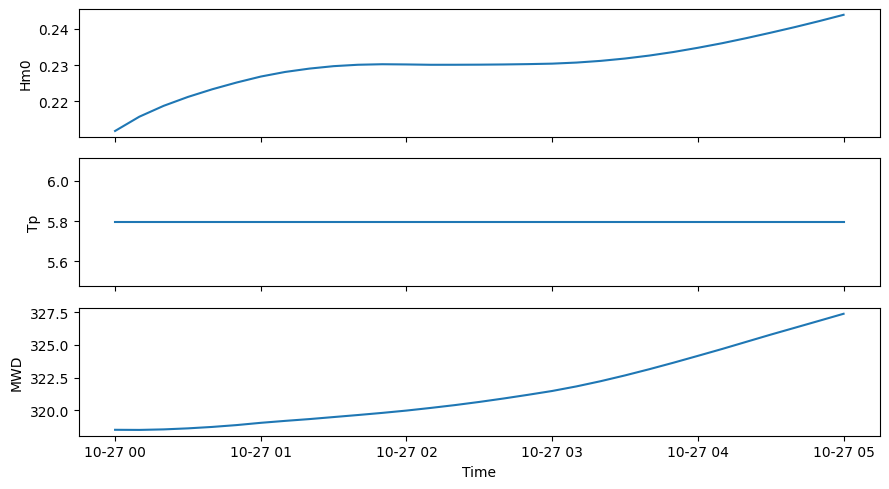

In [8]:
spec.plot.timeseries(params=["Hm0", "Tp", "MWD"], figsize=(9, 5))
plt.tight_layout()
plt.show()

D:\STKI\cloned_repos\pyWSWAT\src\pywswat\_plot.py:180: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(


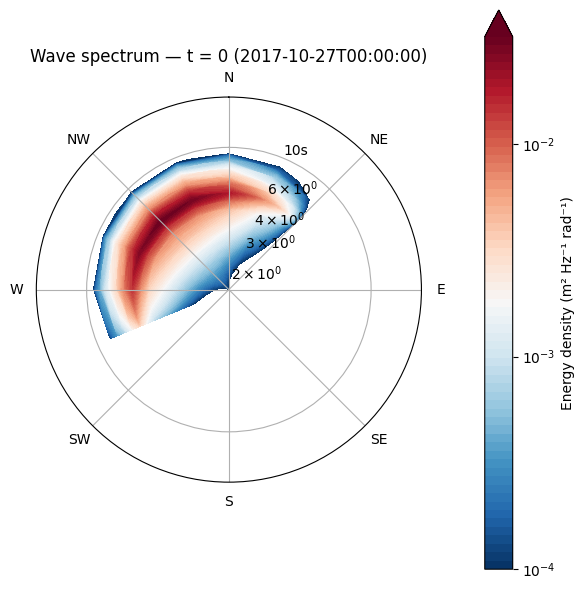

In [9]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="polar")
spec.plot.spectrum(ax=ax, title="Wave spectrum — t = 0")
plt.tight_layout()
plt.show()

## 5. Operations — `sel_freq`, `integrate_dir`, `isel`

All operations return a new **`SpectraArray`** backed by a fresh `mikeio.DataArray`.  
`sel_freq` and `integrate_dir` preserve the original spectral geometry type.

In [10]:
swell    = spec.sel_freq(fmin=0.04, fmax=0.10)
wind_sea = spec.sel_freq(fmin=0.10, fmax=0.50)

print("swell    :", swell)
print()
print("wind_sea :", wind_sea)

swell    : <pywswat.SpectraArray>  name: NoName
dims: (time:31, direction:16, frequency:7)
frequency: 0.055 - 0.097 Hz  (7 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (31 steps)

wind_sea : <pywswat.SpectraArray>  name: NoName
dims: (time:31, direction:16, frequency:17)
frequency: 0.107 - 0.492 Hz  (17 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (31 steps)


In [11]:
spec_1d = spec.integrate_dir()   # frequency spectrum — no direction axis
print(spec_1d)
print()
print("geometry after integrate_dir:", spec_1d.geometry)

<pywswat.SpectraArray>  name: NoName
dims: (time:31, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (31 steps)

geometry after integrate_dir: Point Spectrum Geometry(frequency:25, direction:0)


In [12]:
# Compare Hm0 for each component
components = {"total": spec, "swell": swell, "wind_sea": wind_sea}

print(f"{'Component':<10} {'Hm0 mean (m)':>14} {'Tp mean (s)':>12}")
print("-" * 38)
for name, s in components.items():
    p = s.to_params()
    print(f"{name:<10} {p['Hm0'].values.mean():>14.3f} {p['Tp'].values.mean():>12.2f}")

Component    Hm0 mean (m)  Tp mean (s)
--------------------------------------
total               0.230         5.79
swell               0.002        10.26
wind_sea            0.230         5.79


## 6. Area spectrum — spatial geometry is preserved

For area and line spectra, `sel_freq()` and `integrate_dir()` keep the full spatial mesh  
in the resulting DataArray's geometry — no information is lost.

In [13]:
spec_area = read(DATA / "area_spectra.dfsu", item=0)
print(spec_area)
print()
print("geometry type:", type(spec_area.geometry).__name__)

<pywswat.SpectraArray>  name: Energy density
dims: (time:3, element:40, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (3 steps)

geometry type: GeometryFMAreaSpectrum


In [14]:
# to_params returns (time, location) arrays
ds_area_params = spec_area.to_params()
print(ds_area_params)
print()
print(f"Hm0 shape : {ds_area_params['Hm0'].values.shape}  (time × elements)")
print(f"Hm0 range : {ds_area_params['Hm0'].values.min():.3f} – {ds_area_params['Hm0'].values.max():.3f} m")

<mikeio.Dataset>
dims: (time:3, element:40)
time: 2017-10-27 00:00:00 - 2017-10-27 05:00:00 (3 records)
geometry: Dfsu2D (40 elements, 33 nodes)
items:
  0:  Hm0 <Significant wave height> (meter)
  1:  Tp <Wave period> (second)
  2:  T01 <Wave period> (second)
  3:  T02 <Wave period> (second)
  4:  Tm10 <Wave period> (second)
  5:  MWD <Mean Wave Direction> (degree)
  6:  PWD <Wave direction> (degree)
  7:  DSD <Directional Standard Deviation> (degree)

Hm0 shape : (3, 40)  (time × elements)
Hm0 range : 0.087 – 0.234 m


In [15]:
# sel_freq on area spectrum — GeometryFMAreaSpectrum is preserved
area_swell = spec_area.sel_freq(fmin=0.04, fmax=0.10)
print(f"geometry after sel_freq : {type(area_swell.geometry).__name__}")
print(f"nloc preserved          : {area_swell.nloc} elements")
print(f"nf after sel_freq       : {area_swell.nf} (was {spec_area.nf})")

geometry after sel_freq : GeometryFMAreaSpectrum
nloc preserved          : 40 elements
nf after sel_freq       : 7 (was 25)


In [16]:
# integrate_dir on area spectrum — spatial mesh still intact
area_1d = spec_area.integrate_dir()
print(f"geometry after integrate_dir : {type(area_1d.geometry).__name__}")
print(f"nloc preserved               : {area_1d.nloc} elements")
print(f"has_dir after integrate_dir  : {area_1d.has_dir}")

geometry after integrate_dir : GeometryFMAreaSpectrum
nloc preserved               : 40 elements
has_dir after integrate_dir  : False


In [17]:
# isel — select a single element
spec_elem5 = spec_area.isel(location=5)
print(spec_elem5)
print()
print("geometry type after isel:", type(spec_elem5.geometry).__name__)

<pywswat.SpectraArray>  name: Energy density
dims: (time:3, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (3 steps)

geometry type after isel: GeometryFMPointSpectrum


## 7. Line spectrum

In [18]:
spec_line = read(DATA / "line_spectra.dfsu", item=0)
print(spec_line)
print()

ds_line_params = spec_line.to_params()
print(f"Hm0 shape : {ds_line_params['Hm0'].values.shape}  (time × nodes)")

<pywswat.SpectraArray>  name: Energy density
dims: (time:4, node:10, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (4 steps)

Hm0 shape : (4, 10)  (time × nodes)


In [19]:
# sel_freq preserves GeometryFMLineSpectrum
line_swell = spec_line.sel_freq(0.04, 0.10)
print(f"geometry after sel_freq : {type(line_swell.geometry).__name__}")
print(f"nloc                    : {line_swell.nloc}")

geometry after sel_freq : GeometryFMLineSpectrum
nloc                    : 10


## 8. SpectraSet — wraps `mikeio.Dataset`

Use `SpectraSet` when the file has multiple spectral items or when you want to operate  
on all items at once.

In [20]:
ss = read(DATA / "area_spectra.dfsu")   # all items as SpectraSet
print(type(ss).__name__)
print(ss)

SpectraSet
<pywswat.SpectraSet>
dims: (time:3, element:40, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz
direction: 0 - 338 deg
time: 2017-10-27T00:00:00 - 2017-10-27T05:00:00  (3 steps)
items:
  0: Energy density


In [21]:
# Indexing
print("ss[0]        :", type(ss[0]).__name__)          # SpectraArray
print("ss[0:1]      :", type(ss[0:1]).__name__)        # SpectraSet
print("ss.ds        :", type(ss.ds).__name__)           # underlying mikeio.Dataset

ss[0]        : SpectraArray
ss[0:1]      : SpectraSet
ss.ds        : Dataset


In [22]:
# to_params() on SpectraSet — single item → plain names
params = ss.to_params()
print(type(params).__name__)   # mikeio.Dataset
print(params)

Dataset
<mikeio.Dataset>
dims: (time:3, element:40)
time: 2017-10-27 00:00:00 - 2017-10-27 05:00:00 (3 records)
geometry: Dfsu2D (40 elements, 33 nodes)
items:
  0:  Hm0 <Significant wave height> (meter)
  1:  Tp <Wave period> (second)
  2:  T01 <Wave period> (second)
  3:  T02 <Wave period> (second)
  4:  Tm10 <Wave period> (second)
  5:  MWD <Mean Wave Direction> (degree)
  6:  PWD <Wave direction> (degree)
  7:  DSD <Directional Standard Deviation> (degree)


In [23]:
# Batch sel_freq on SpectraSet
ss_swell = ss.sel_freq(fmin=0.04, fmax=0.10)
print("ss_swell type :", type(ss_swell).__name__)
print("nf after      :", ss_swell.freq.shape[0], "(was", ss.freq.shape[0], ")")

ss_swell type : SpectraSet
nf after      : 7 (was 25 )


In [24]:
# Multi-item SpectraSet — to_params() prefixes names with item name
da = mikeio.read(str(DATA / "area_spectra.dfsu"))[0]
da_swell    = mikeio.DataArray(da.values, time=da.time, geometry=da.geometry, name="swell")
da_wind_sea = mikeio.DataArray(da.values, time=da.time, geometry=da.geometry, name="wind_sea")
ss_multi = SpectraSet(mikeio.Dataset([da_swell, da_wind_sea]))

params_multi = ss_multi.to_params()
print("Parameter names for multi-item SpectraSet:")
print(params_multi.names)

Parameter names for multi-item SpectraSet:
['swell_Hm0', 'swell_Tp', 'swell_T01', 'swell_T02', 'swell_Tm10', 'swell_MWD', 'swell_PWD', 'swell_DSD', 'wind_sea_Hm0', 'wind_sea_Tp', 'wind_sea_T01', 'wind_sea_T02', 'wind_sea_Tm10', 'wind_sea_MWD', 'wind_sea_PWD', 'wind_sea_DSD']


## 9. Fitting into an existing mikeio workflow

All pywswat classes accept and return mikeio objects, so they slot  
into any mikeio pipeline with no extra conversion.

In [25]:
# 1. Load with mikeio, operate with mikeio, then hand to pywswat
ds_raw   = mikeio.read(str(DATA / "pt_spectra.dfsu"))
da_window = ds_raw[0].isel(time=range(0, 10))   # mikeio time-slice

spec_window = SpectraArray(da_window)
print(spec_window)

# 2. Compute parameters
ds_window_params = spec_window.to_params()

# 3. Write results back with mikeio
# ds_window_params.to_dfs0("window_params.dfs0")

print("\nHm0 over window:")
print(np.round(ds_window_params["Hm0"].values, 3))

<pywswat.SpectraArray>  name: Point 1: Energy density
dims: (time:10, direction:16, frequency:25)
frequency: 0.055 - 0.542 Hz  (25 bins)
direction: 0 - 338 deg  (16 bins)
time: 2017-10-27T00:00:00 - 2017-10-27T01:30:00  (10 steps)

Hm0 over window:
[0.212 0.216 0.219 0.221 0.223 0.225 0.227 0.228 0.229 0.23 ]


In [26]:
# Access the underlying mikeio DataArray at any time
da_back = spec.da            # zero copy — the original DA
da_swell_back = swell.da    # reconstructed DA with reduced frequency axis

print("Original DA    :", da_back)
print()
print("Swell DA (sel_freq result):")
print(da_swell_back)

Original DA    : <mikeio.DataArray>
name: Point 1: Energy density
dims: (time:31, direction:16, frequency:25)
time: 2017-10-27 00:00:00 - 2017-10-27 05:00:00 (31 records)
geometry: Point Spectrum Geometry(frequency:25, direction:16)


Swell DA (sel_freq result):
<mikeio.DataArray>
name: NoName
dims: (time:31, direction:16, frequency:7)
time: 2017-10-27 00:00:00 - 2017-10-27 05:00:00 (31 records)
geometry: Point Spectrum Geometry(frequency:7, direction:16)

